In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

import torch
torch.set_num_threads(2)
torch.set_num_interop_threads(2)
torch.cuda.set_device(3)
print(f"Using GPU: {torch.cuda.current_device()} "
      f"({torch.cuda.get_device_name(3)})")

Using GPU: 3 (Quadro RTX 6000)


In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%matplotlib notebook
from argparse import ArgumentParser
import yaml
import os
import math
import torch
# from torch import vmap
from torch.func import vmap, grad
from models import FNN2d
from train_utils import Adam

from solver.BlackScholesEq import BlackScholesEq1D
import traceback

import scipy.io
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import numpy as np
import imageio


from tqdm import tqdm
from train_utils.utils import save_checkpoint, load_checkpoint, update_config, load_config
from train_utils.losses import LpLoss
import train_utils.datasets as datasets
from importlib import reload
reload(datasets)
from train_utils.datasets import DataLoaderBS

try:
    import wandb
except ImportError:
    wandb = None


# Solver Sanity Check

Verify the reference Crank–Nicolson solver before generating training data. We march backward in **τ = T − t** from the terminal payoff (τ = 0) to today's price (τ = T).

device: cuda
solution shape: (51, 256)   # (n_snapshots, Nx)
first tau: 0.0000, last tau: 1.0000


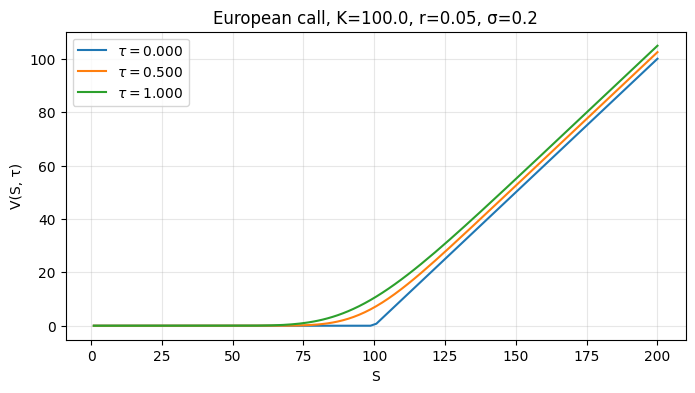

relative L2 error vs analytical BS at τ=T: 4.3633e-05


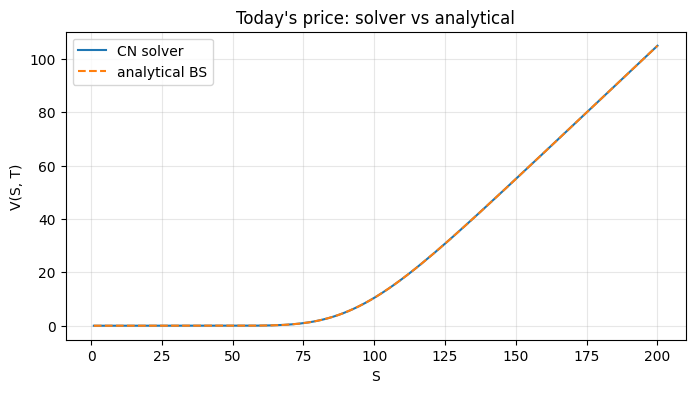

In [3]:
%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Problem parameters
K = 100.0          # strike
r = 0.05           # risk-free rate
sigma = 0.2        # volatility
T = 1.0            # time to maturity
S_min, S_max = 1.0, 200.0
Nx = 256
dtau = 1e-3

bs = BlackScholesEq1D(
    S_min=S_min, S_max=S_max, Nx=Nx,
    r=r, sigma=sigma, dtau=dtau, T=T,
    device=device,
)

# Terminal payoff is the initial condition in tau coordinates
v0 = bs.call_payoff(K)
bc_lo, bc_hi = bs.call_bcs(K)

# Save ~50 snapshots over [0, T]
save_interval = max(1, int(T / dtau / 50))
V = bs.bs_driver(v0, bc_lo, bc_hi, save_interval=save_interval)

S = bs.S_grid.detach().cpu()
tau_list = bs.T_list

print(f'device: {device}')
print(f'solution shape: {tuple(V.shape)}   # (n_snapshots, Nx)')
print(f'first tau: {tau_list[0]:.4f}, last tau: {tau_list[-1]:.4f}')

# Plot a few tau slices
fig, ax = plt.subplots(figsize=(8, 4))
for idx in [0, len(V) // 2, -1]:
    ax.plot(S, V[idx].detach().cpu(), label=fr'$\tau={tau_list[idx]:.3f}$')
ax.set_xlabel('S')
ax.set_ylabel('V(S, τ)')
ax.set_title(f'European call, K={K}, r={r}, σ={sigma}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Optional: compare final slice to closed-form Black–Scholes at t=0
def bs_call_price(S, K, r, sigma, T_rem):
    """Analytical European call; T_rem = time to maturity."""
    S = torch.as_tensor(S, dtype=torch.float64)
    if T_rem <= 0:
        return torch.clamp(S - K, min=0.0)
    d1 = (torch.log(S / K) + (r + 0.5 * sigma**2) * T_rem) / (sigma * math.sqrt(T_rem))
    d2 = d1 - sigma * math.sqrt(T_rem)
    from torch.special import ndtr
    return S * ndtr(d1) - K * math.exp(-r * T_rem) * ndtr(d2)

V_final = V[-1].detach().cpu()
V_exact = bs_call_price(S, K, r, sigma, T).cpu()
rel_err = torch.norm(V_final - V_exact) / torch.norm(V_exact)
print(f'relative L2 error vs analytical BS at τ=T: {rel_err.item():.4e}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S, V_final, label='CN solver')
ax.plot(S, V_exact, '--', label='analytical BS')
ax.set_xlabel('S')
ax.set_ylabel('V(S, T)')
ax.set_title('Today\'s price: solver vs analytical')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Define Loss Functions

## Finite Difference Residual

In [4]:
def FDM_BlackScholes(u, D=1.0, r=0.05, sigma=0.2, T=1.0, S_min=1.0, S_max=200.0):
    """
    Black-Scholes PDE residual on a normalized (tau_norm, x_norm) grid.

    PDE in log-price x=log(S) and tau=T-t:
        V_tau = a*V_xx + b*V_x - r*V,  a=0.5*sigma^2, b=r-0.5*sigma^2

    DataLoader coordinates: tau_norm in [0,1] -> [0,T], x_norm in [0,1] -> log(S) in [log(S_min), log(S_max)].
    Coefficients are scaled accordingly.

    u : [batch, Ntau, Nx]
    Returns residual of shape [batch, Ntau-2, Nx-2].
    """
    batchsize = u.size(0)
    nt = u.size(1)
    nx = u.size(2)
    u = u.reshape(batchsize, nt, nx)

    dt = D / (nt - 1)   # normalized tau spacing
    dx = D / nx          # normalized log-S spacing

    Lx    = math.log(S_max / S_min)
    a     = 0.5 * sigma ** 2
    b     = r - 0.5 * sigma ** 2
    a_eff = a * T / Lx ** 2
    b_eff = b * T / Lx
    r_eff = r * T

    ux  = (u[:, :, 2:] - u[:, :, :-2])                        / (2.0 * dx)
    uxx = (u[:, :, 2:] - 2.0 * u[:, :, 1:-1] + u[:, :, :-2]) / dx ** 2
    utau = (u[:, 2:, :] - u[:, :-2, :]) / (2.0 * dt)

    Du = (utau[:, :, 1:-1]
          - a_eff * uxx[:, 1:-1, :]
          - b_eff * ux[:, 1:-1, :]
          + r_eff * u[:, 1:-1, 1:-1])
    return Du


def PINO_loss_bs(u, u0, r=0.05, sigma=0.2, T=1.0, S_min=1.0, S_max=200.0):
    """
    PINO loss: IC matching + Black-Scholes PDE residual.

    u  : [batch, Ntau, Nx]  full solution predicted by model
    u0 : [batch, Nx]        payoff (initial condition at tau=0)
    """
    batchsize = u.size(0)
    nt = u.size(1)
    nx = u.size(2)
    u = u.reshape(batchsize, nt, nx)

    loss_u = F.mse_loss(u[:, 0, :], u0)

    Du = FDM_BlackScholes(u, r=r, sigma=sigma, T=T, S_min=S_min, S_max=S_max)
    loss_f = F.mse_loss(Du, torch.zeros_like(Du))

    return loss_u, loss_f

# Define Training Function

In [5]:
def train_bs(model,
             train_loader,
             optimizer,
             scheduler,
             config,
             rank=0,
             log=False,
             project='PINO-BlackScholes-default',
             group='default',
             tags=['default'],
             use_tqdm=True):
    if rank == 0 and wandb and log:
        run = wandb.init(project=project,
                         entity='shawngr2',
                         group=group,
                         config=config,
                         tags=tags, reinit=True,
                         settings=wandb.Settings(start_method='fork'))

    data_weight = config['train']['xy_loss']
    f_weight    = config['train']['f_loss']
    ic_weight   = config['train']['ic_loss']
    r     = config['data']['r']
    sigma = config['data']['sigma']
    T     = config['data']['T']
    S_min = config['data']['S_min']
    S_max = config['data']['S_max']
    ckpt_freq = config['train']['ckpt_freq']

    model.train()
    myloss = LpLoss(size_average=True)
    pbar = range(config['train']['epochs'])
    if use_tqdm:
        pbar = tqdm(pbar, dynamic_ncols=True, smoothing=0.1)

    for e in pbar:
        model.train()
        train_pino = 0.0
        data_l2    = 0.0
        train_ic   = 0.0
        train_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(rank), y.to(rank)
            out = model(x).reshape(y.shape)
            data_loss = myloss(out, y)

            loss_ic, loss_f = PINO_loss_bs(
                out, x[:, 0, :, 0],
                r=r, sigma=sigma, T=T, S_min=S_min, S_max=S_max)
            total_loss = loss_ic * ic_weight + loss_f * f_weight + data_loss * data_weight

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            data_l2    += data_loss.item()
            train_pino += loss_f.item()
            train_loss += total_loss.item()
            train_ic   += loss_ic.item()

        scheduler.step()
        data_l2    /= len(train_loader)
        train_pino /= len(train_loader)
        train_loss /= len(train_loader)
        train_ic   /= len(train_loader)

        if use_tqdm:
            pbar.set_description(
                f'Epoch {e}, train loss: {train_loss:.5f} '
                f'train f error: {train_pino:.5f}; '
                f'data l2 error: {data_l2:.5f}; '
                f'train ic error: {train_ic:.5f}'
            )
        if wandb and log:
            wandb.log({
                'Train f error':  train_pino,
                'Train L2 error': data_l2,
                'Train ic error': train_ic,
                'Train loss':     train_loss,
            })

        if e % ckpt_freq == 0:
            save_checkpoint(config['train']['save_dir'],
                            config['train']['save_name'].replace('.pt', f'_{e}.pt'),
                            model, optimizer)

    save_checkpoint(config['train']['save_dir'],
                    config['train']['save_name'],
                    model, optimizer)
    print('Done!')

# Evaluation Function

In [6]:
def eval_bs(model,
            dataloader,
            config,
            device,
            use_tqdm=True):
    model.eval()
    myloss = LpLoss(size_average=True)
    r     = config['data']['r']
    sigma = config['data']['sigma']
    T     = config['data']['T']
    S_min = config['data']['S_min']
    S_max = config['data']['S_max']

    pbar = tqdm(dataloader, dynamic_ncols=True, smoothing=0.05) if use_tqdm else dataloader

    test_err = []
    f_err    = []

    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            out = model(x).reshape(y.shape)
            data_loss = myloss(out, y)

            _, f_loss = PINO_loss_bs(
                out, x[:, 0, :, 0],
                r=r, sigma=sigma, T=T, S_min=S_min, S_max=S_max)
            test_err.append(data_loss.item())
            f_err.append(f_loss.item())

    mean_f_err = np.mean(f_err)
    std_f_err  = np.std(f_err, ddof=1) / np.sqrt(len(f_err))
    mean_err   = np.mean(test_err)
    std_err    = np.std(test_err, ddof=1) / np.sqrt(len(test_err))

    print(f'==Averaged relative L2 error mean: {mean_err}, std error: {std_err}==\n'
          f'==Averaged equation error mean: {mean_f_err}, std error: {std_f_err}==')

# Save and Load Data

In [7]:
def save_data(data_path, test_x, test_y, preds_y):
    data_dir, _ = os.path.split(data_path)
    os.makedirs(data_dir, exist_ok=True)
    np.savez(data_path, test_x=test_x, test_y=test_y, preds_y=preds_y)

def load_data(data_path):
    data = np.load(data_path)
    return data['test_x'], data['test_y'], data['preds_y']

# Visualization

In [ ]:
def plot_predictions(key, test_x, test_y, preds_y,
                     S_min=1.0, S_max=200.0,
                     save_path=None, font_size=None):
    if font_size is not None:
        plt.rcParams.update({'font.size': font_size})

    pred = preds_y[key]
    true = test_y[key]
    a    = test_x[key]

    Ntau, Nx, _ = a.shape
    payoff   = a[0, :, 0]
    x_norm   = a[0, :, 1]
    tau_norm = a[:, 0, 2]

    Lx = math.log(S_max / S_min)
    S  = np.exp(np.log(S_min) + x_norm * Lx)

    slice_indices = sorted({0, Ntau // 2, Ntau - 1})
    slice_labels = [f'$tau={tau_norm[i]:.3f}$' for i in slice_indices]

    fig = plt.figure(figsize=(23, 5))

    plt.subplot(1, 4, 1)
    plt.plot(S, payoff)
    plt.xlabel('$S$')
    plt.ylabel('$V$')
    plt.title('Payoff $V(S, tau=0)$')
    plt.xlim([S_min, S_max])
    plt.tight_layout()

    def plot_line_panel(values, title, ylabel):
        for idx, label in zip(slice_indices, slice_labels):
            plt.plot(S, values[idx], label=label)
        plt.xlabel('$S$')
        plt.ylabel(ylabel)
        plt.title(title)
        plt.xlim([S_min, S_max])
        plt.grid(alpha=0.25)
        plt.legend(fontsize=8)
        plt.tight_layout()

    plt.subplot(1, 4, 2)
    plot_line_panel(true, 'Exact $V(S, tau)$', '$V$')

    plt.subplot(1, 4, 3)
    plot_line_panel(pred, 'Predict $V(S, tau)$', '$V$')

    plt.subplot(1, 4, 4)
    plot_line_panel(pred - true, 'Absolute Error', 'Error')

    if save_path is not None:
        if save_path.endswith((os.sep, '/', '\\')) or os.path.isdir(save_path):
            os.makedirs(save_path, exist_ok=True)
            save_file = os.path.join(save_path, f'plot_predictions_{key}.png')
        else:
            os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
            save_file = save_path if save_path.lower().endswith('.png') else f'{save_path}.png'
        plt.savefig(save_file, bbox_inches='tight')
    # plt.show()

# Movies

In [9]:
def generate_movie_1D(key, test_x, test_y, preds_y,
                      S_min=1.0, S_max=200.0,
                      plot_title='Black-Scholes',
                      movie_dir='', movie_name='movie.gif',
                      frame_basename='movie', frame_ext='jpg',
                      remove_frames=True, font_size=None):
    frame_files = []
    os.makedirs(movie_dir, exist_ok=True)
    if font_size is not None:
        plt.rcParams.update({'font.size': font_size})

    pred = preds_y[key]
    true = test_y[key]
    a    = test_x[key]

    Ntau, Nx, _ = a.shape
    x_norm   = a[0, :, 1]
    tau_norm = a[:, 0, 2]
    Lx = math.log(S_max / S_min)
    S  = np.exp(np.log(S_min) + x_norm * Lx)

    fig = plt.figure(figsize=(6, 5))
    ax  = fig.add_subplot(111)
    plt.ion()
    fig.show()
    fig.canvas.draw()

    ax.plot(S, true[0], 'b-',  label='Exact')
    ax.plot(S, pred[0], 'r--', label='PINO Prediction')
    ylim = plt.ylim()
    plt.tight_layout()

    for i in range(Ntau):
        ax.clear()
        ax.plot(S, true[i], 'b-',  label='Exact')
        ax.plot(S, pred[i], 'r--', label='PINO Prediction')
        plt.xlabel('$S$')
        plt.ylabel('$V$')
        plt.title(f'{plot_title}  tau={tau_norm[i]:.2f}')
        plt.legend(loc='upper left')
        plt.ylim(ylim)
        plt.xlim([S_min, S_max])
        plt.tight_layout()
        fig.canvas.draw()

        if movie_dir:
            frame_path = os.path.join(movie_dir, f'{frame_basename}-{i:03}.{frame_ext}')
            frame_files.append(frame_path)
            plt.savefig(frame_path)

    if movie_dir:
        movie_path = os.path.join(movie_dir, movie_name)
        with imageio.get_writer(movie_path, mode='I') as writer:
            for frame in frame_files:
                writer.append_data(imageio.imread(frame))

    if movie_dir and remove_frames:
        for frame in frame_files:
            try:
                os.remove(frame)
            except Exception:
                pass

# Load Config File

In [10]:
config_file = 'configs/custom/black_scholes-0000.yaml'
config = load_config(config_file)
display(config)

{'data': {'name': 'BlackScholes-0000',
  'total_num': 10,
  'n_train': 8,
  'n_test': 2,
  'nx': 512,
  'nt': 100,
  'sub': 4,
  'sub_t': 4,
  'r': 0.05,
  'sigma': 0.2,
  'T': 1.0,
  'S_min': 1.0,
  'S_max': 200.0,
  'K_min': 60.0,
  'K_max': 140.0},
 'model': {'layers': [16, 24, 24, 32, 32],
  'modes1': [15, 12, 9, 9],
  'modes2': [15, 12, 9, 9],
  'fc_dim': 128,
  'activation': 'gelu'},
 'train': {'batchsize': 20,
  'epochs': 500,
  'milestones': [150, 300, 450],
  'base_lr': 0.001,
  'scheduler_gamma': 0.5,
  'ic_loss': 5.0,
  'f_loss': 1.0,
  'xy_loss': 10.0,
  'save_dir': 'BlackScholes',
  'save_name': 'BlackScholes-eqn.pt',
  'ckpt': 'checkpoints/BlackScholes/BlackScholes-eqn.pt',
  'ckpt_freq': 100},
 'log': {'project': 'PINO-BlackScholes', 'group': 'BlackScholes-0000'},
 'test': {'batchsize': 1,
  'ckpt': 'checkpoints/BlackScholes/BlackScholes-eqn.pt'}}

# Parameters

In [11]:
Nsamples = config['data']['total_num']
N        = config['data']['nx']
Nt0      = config['data']['nt']
sub_x    = config['data']['sub']
sub_t    = config['data']['sub_t']
Nx       = N // sub_x
Nt       = Nt0 // sub_t + 1

r     = config['data']['r']
sigma = config['data']['sigma']
T     = config['data']['T']
S_min = config['data']['S_min']
S_max = config['data']['S_max']
K_min = config['data']['K_min']
K_max = config['data']['K_max']

# Solver step size and snapshot interval
dtau_solve  = 1e-3                           # fine CN step for accuracy
steps_total = int(T / dtau_solve)            # e.g. 1000
save_int    = max(1, steps_total // Nt0)     # e.g. 10 -> 101 snapshots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
print(f'Nx={Nx}, Nt={Nt}, save_int={save_int}')

device: cuda
Nx=128, Nt=26, save_int=10


# Generate Dataset

Sample `Nsamples` strike prices K uniformly from [K_min, K_max],
compute the European call payoff for each K, and run the Crank-Nicolson solver.

In [12]:
bs_solver = BlackScholesEq1D(
    S_min=S_min, S_max=S_max, Nx=N,
    r=r, sigma=sigma, dtau=dtau_solve, T=T,
    device=device,
)

K_samples = torch.linspace(K_min, K_max, Nsamples)

A0_list = []   # payoffs  [Nx]
U_list  = []   # solutions [Ntau_snaps, Nx]

for K_i in tqdm(K_samples, desc='Generating BS data'):
    K_val = K_i.item()
    v0         = bs_solver.call_payoff(K_val)
    bc_lo, bc_hi = bs_solver.call_bcs(K_val)
    V = bs_solver.bs_driver(v0, bc_lo, bc_hi, save_interval=save_int)
    A0_list.append(v0.cpu().float())
    U_list.append(V.cpu().float())

a = torch.stack(A0_list)   # [Nsamples, Nx_full]
u = torch.stack(U_list)    # [Nsamples, Ntau_snaps, Nx_full]
display(a.shape, u.shape)

Generating BS data: 100%|██████████| 10/10 [09:44<00:00, 58.50s/it]


torch.Size([10, 512])

torch.Size([10, 101, 512])

In [13]:
dataset = DataLoaderBS(a, u, config['data']['nx'], config['data']['nt'],
                       config['data']['sub'], config['data']['sub_t'])
train_loader = dataset.make_loader(config['data']['n_train'],
                                   config['train']['batchsize'],
                                   start=0, train=True)
test_loader  = dataset.make_loader(config['data']['n_test'],
                                   config['test']['batchsize'],
                                   start=config['data']['n_train'], train=False)

In [14]:
log = False
model = FNN2d(modes1=config['model']['modes1'],
              modes2=config['model']['modes2'],
              fc_dim=config['model']['fc_dim'],
              layers=config['model']['layers'],
              activation=config['model']['activation']).to(device)

optimizer = Adam(model.parameters(), betas=(0.9, 0.999),
                 lr=config['train']['base_lr'])
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=config['train']['milestones'],
    gamma=config['train']['scheduler_gamma'])

# Load from Checkpoint

In [15]:
load_checkpoint(model, ckpt_path=config['train']['ckpt'], optimizer=None)

Weights loaded from checkpoints/BlackScholes/BlackScholes-eqn.pt


# Train the Model

In [16]:
train_bs(model,
         train_loader,
         optimizer,
         scheduler,
         config,
         rank=device,
         log=log,
         project=config['log']['project'],
         group=config['log']['group'])

Epoch 17, train loss: 4.63882 train f error: 0.27078; data l2 error: 0.04004; train ic error: 0.79353:   2%|▏         | 10/500 [00:00<00:22, 21.93it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_0.pt


Epoch 117, train loss: 0.03606 train f error: 0.01035; data l2 error: 0.00221; train ic error: 0.00073:  22%|██▏       | 110/500 [00:01<00:05, 76.39it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_100.pt


Epoch 217, train loss: 0.03015 train f error: 0.00708; data l2 error: 0.00201; train ic error: 0.00059:  44%|████▎     | 218/500 [00:02<00:03, 83.53it/s]

...

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_300.pt


Epoch 417, train loss: 0.02722 train f error: 0.00599; data l2 error: 0.00187; train ic error: 0.00051:  82%|████████▏ | 410/500 [00:05<00:01, 86.66it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_400.pt


Epoch 499, train loss: 0.02672 train f error: 0.00583; data l2 error: 0.00184; train ic error: 0.00049: 100%|██████████| 500/500 [00:06<00:00, 82.19it/s]


Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn.pt
Done!


# Evaluate on Test Data

In [17]:
eval_bs(model, test_loader, config, device)

100%|██████████| 2/2 [00:00<00:00, 88.69it/s]

==Averaged relative L2 error mean: 0.03705141134560108, std error: 0.017455631867051125==
==Averaged equation error mean: 1.8111970126628876, std error: 1.146107703447342==


In [18]:
Nx = config['data']['nx'] // config['data']['sub']
Nt = config['data']['nt'] // config['data']['sub_t'] + 1
Ntest = config['data']['n_test']
model.eval()
test_x = np.zeros((Ntest,Nt,Nx,3))
preds_y = np.zeros((Ntest,Nt,Nx))
test_y = np.zeros((Ntest,Nt,Nx))
with torch.no_grad():
    for i, data in enumerate(test_loader):
        data_x, data_y = data
        data_x, data_y = data_x.to(device), data_y.to(device)
        pred_y = model(data_x).reshape(data_y.shape)
        test_x[i] = data_x.cpu().numpy()
        test_y[i] = data_y.cpu().numpy()
        preds_y[i] = pred_y.cpu().numpy()
#     data_loss = myloss(out, y)

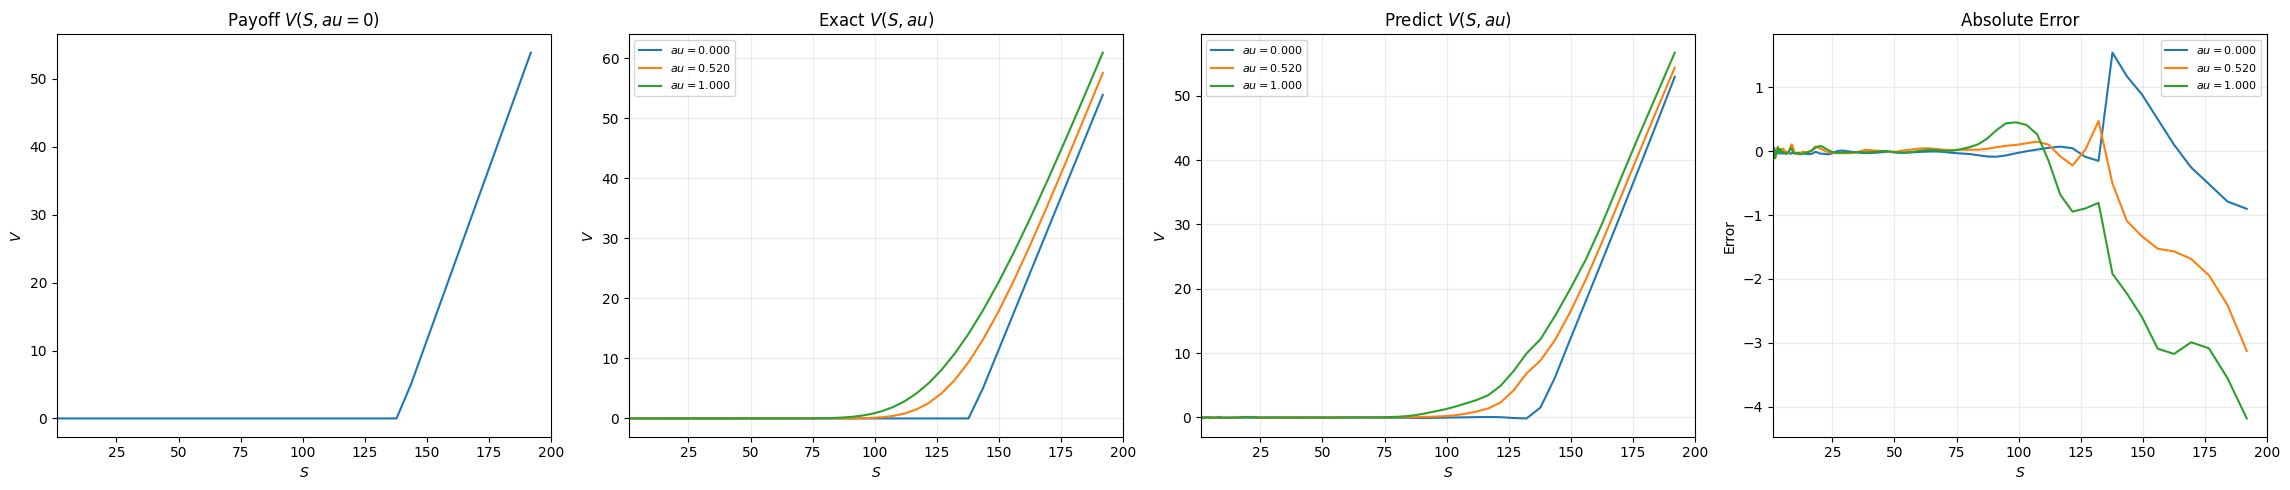

In [39]:
plot_predictions(key, test_x, test_y, preds_y, 1, 200, save_path="BlackScholes/figures/")